In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/NepalStockData/Nepal_Stock_Data/main/Nepse_Data/Life_Insurance/HLI.csv"
df = pd.read_csv(url)

In [5]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,1,2026-09-14,295.0,306.0,294.0,304.0,3.40,"31,870.00","9,582,120.80"
1,2,2026-09-11,292.0,295.7,290.0,294.0,1.27,"23,094.00","6,763,240.40"
2,3,2026-09-10,296.0,296.0,288.7,290.3,-1.93,"17,464.00","5,084,812.60"
3,4,2026-09-09,296.6,297.1,295.9,296.0,-0.20,"8,925.00","2,643,703.30"
4,5,2026-09-07,295.0,300.0,295.0,296.6,0.54,"18,552.00","5,513,043.40"


In [8]:
df.iloc[:,1:]

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,2026-09-14,295.0,306.0,294.0,304.0,3.40,"31,870.00","9,582,120.80"
1,2026-09-11,292.0,295.7,290.0,294.0,1.27,"23,094.00","6,763,240.40"
2,2026-09-10,296.0,296.0,288.7,290.3,-1.93,"17,464.00","5,084,812.60"
3,2026-09-09,296.6,297.1,295.9,296.0,-0.20,"8,925.00","2,643,703.30"
4,2026-09-07,295.0,300.0,295.0,296.6,0.54,"18,552.00","5,513,043.40"
...,...,...,...,...,...,...,...,...
733,2023-06-28,517.0,557.9,517.0,557.9,10.00,"1,523,712.00","837,036,791.90"
734,2023-06-27,470.3,507.2,470.3,507.2,10.00,"24,091.00","12,154,377.30"
735,2023-06-26,420.0,461.1,420.0,461.1,10.00,"4,364.00","2,009,685.70"
736,2023-06-25,388.7,419.2,388.7,419.2,10.00,"5,728.00","2,400,285.70"


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738 entries, 0 to 737
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.N.      738 non-null    int64  
 1   Date      738 non-null    object 
 2   Open      738 non-null    float64
 3   High      738 non-null    float64
 4   Low       738 non-null    float64
 5   Ltp       738 non-null    float64
 6   % Change  738 non-null    float64
 7   Qty       738 non-null    object 
 8   Turnover  738 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 52.0+ KB


In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [20]:
cols = ['Open','High','Low','Ltp','% Change','Qty','Turnover']
for col in cols:
    df[col] = df[col].astype(str).str.replace (',', '')
    df[col] = pd.to_numeric(df[col])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738 entries, 0 to 737
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   S.N.      738 non-null    int64         
 1   Date      738 non-null    datetime64[ns]
 2   Open      738 non-null    float64       
 3   High      738 non-null    float64       
 4   Low       738 non-null    float64       
 5   Ltp       738 non-null    float64       
 6   % Change  738 non-null    float64       
 7   Qty       738 non-null    float64       
 8   Turnover  738 non-null    float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 52.0 KB


In [27]:
df['zscore'] = (df['Ltp'] - df['Ltp'].mean())/df['Ltp'].std()

In [31]:
print(df['zscore'])

0     -2.027400
1     -2.222770
2     -2.295057
3     -2.183696
4     -2.171974
         ...   
733    2.933052
734    1.942525
735    1.041868
736    0.223266
737   -0.521095
Name: zscore, Length: 738, dtype: float64


In [33]:
df.loc[df['Ltp'].idxmax()], ['Date','Ltp','Turnover']

(S.N.                        475
 Date        2024-08-12 00:00:00
 Open                      520.0
 High                      576.4
 Low                       520.0
 Ltp                       576.4
 % Change                   10.0
 Qty                   1021936.0
 Turnover            572543881.0
 zscore                 3.294487
 Name: 474, dtype: object,
 ['Date', 'Ltp', 'Turnover'])

In [36]:
df.nlargest(10, 'Ltp') [['Date','Ltp','Turnover','% Change','High']]

,Date,Ltp,Turnover,% Change,High
474,2024-08-12,576.4,572543881.0,10.00,576.4
473,2024-08-13,570.0,336855030.5,-1.11,607.0
472,2024-08-14,568.9,279650497.9,-0.19,581.0
471,2024-08-15,564.0,290820162.2,-0.86,584.9
733,2023-06-28,557.9,837036791.9,10.00,557.9
732,2023-07-02,549.0,425654707.9,-1.60,574.0
470,2024-08-18,544.0,263533906.2,-3.55,574.0
468,2024-08-22,538.1,168500969.3,0.00,550.0
469,2024-08-21,538.1,122295474.4,-1.08,554.8
731,2023-07-03,532.0,239445785.1,-3.10,549.0


<Axes: xlabel='Date', ylabel='Ltp'>

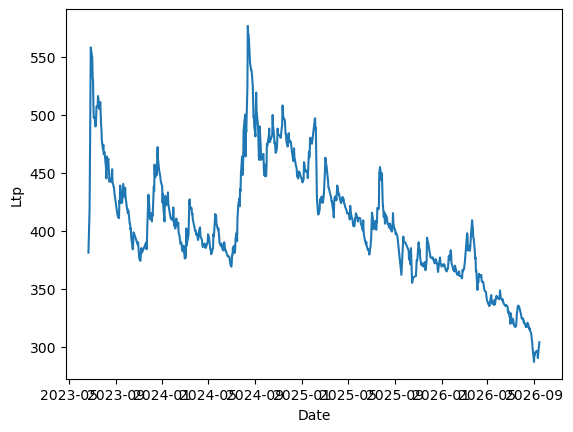

In [40]:
sns.lineplot(data=df, x="Date", y="Ltp") 

In [51]:
df.loc[df['Turnover'].idxmax()]

S.N.                        734
Date        2023-06-28 00:00:00
Open                      517.0
High                      557.9
Low                       517.0
Ltp                       557.9
% Change                   10.0
Qty                   1523712.0
Turnover            837036791.9
zscore                 2.933052
Name: 733, dtype: object

In [52]:
df.nlargest(10, 'Turnover')[
    ['Date','Ltp','Turnover','% Change']
    ]

,Date,Ltp,Turnover,% Change
733,2023-06-28,557.9,837036791.9,10.00
474,2024-08-12,576.4,572543881.0,10.00
732,2023-07-02,549.0,425654707.9,-1.60
475,2024-08-11,524.0,385179932.3,8.04
473,2024-08-13,570.0,336855030.5,-1.11
480,2024-08-01,486.9,324085078.9,5.39
471,2024-08-15,564.0,290820162.2,-0.86
472,2024-08-14,568.9,279650497.9,-0.19
470,2024-08-18,544.0,263533906.2,-3.55
478,2024-08-06,464.0,260100708.4,-7.20


In [54]:
#outlier detection
seventy = df['Ltp'].quantile(0.75)
twenty = df['Ltp'].quantile(0.25)
iqr = seventy - twenty
print(iqr)

65.97500000000002


In [55]:
upper = seventy+(1.5*iqr)
lower = twenty-(1.5*iqr)

In [56]:
print(upper, lower)

540.9375 277.03749999999997


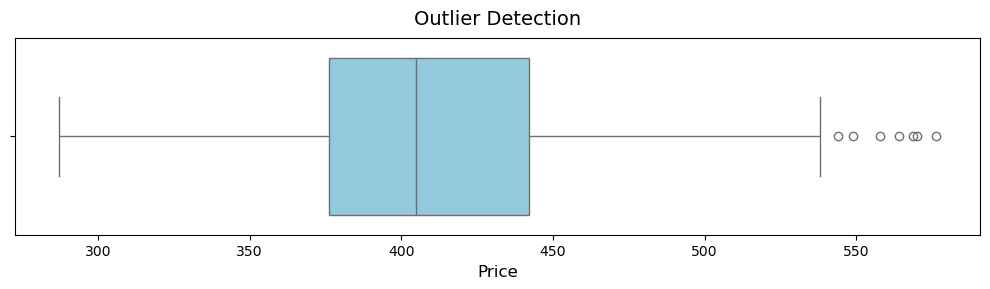

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Ltp'], color='skyblue')
plt.title('Outlier Detection', fontsize=14, pad=10)
plt.xlabel('Price', fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
seventy_fifth = df['Turnover'].quantile(0.75)
twenty_five = df['Turnover'].quantile(0.25)
iqr_t = seventy_fifth - twenty_five
print(iqr_t)

23887102.674999997


In [63]:
upper_u = seventy_fifth + (1.5-iqr_t)
lower_l = twenty_five - (1.5-iqr_t)
print(upper_u, lower_l)

13048191.375 36935291.05


In [70]:
df['Date_24'] = (
    (df['Date'] >= '2024-01-01') &
    (df['Date'] <= '2024-12-31')
)

In [80]:
df_24 =df[df['Date_24']].copy()

In [82]:
df_24['Turnover'].describe()

count    2.320000e+02
mean     5.218592e+07
std      7.239957e+07
min      4.498575e+06
25%      1.638686e+07
50%      2.623064e+07
75%      4.844529e+07
max      5.725439e+08
Name: Turnover, dtype: float64

In [83]:
df_24.dtypes

S.N.                 int64
Date        datetime64[ns]
Open               float64
High               float64
Low                float64
Ltp                float64
% Change           float64
Qty                float64
Turnover           float64
zscore             float64
Date_24               bool
dtype: object

In [84]:
print("Total_Turnover:", df_24['Turnover'].sum())
print("Average_Turnover:", df_24['Turnover'].mean())
print("Minimum_Turnover:", df_24['Turnover'].min())
print("Maximum_Turnover:", df_24['Turnover'].max())

Total_Turnover: 12107133038.5
Average_Turnover: 52185918.26939655
Minimum_Turnover: 4498575.0
Maximum_Turnover: 572543881.0
